# Análisis de Precipitación CHIRPS para El Salvador

Este cuaderno recupera datos diarios de precipitación desde ERDDAP (CHIRPS v2.0), calcula acumulados mensuales, una climatología mensual y las anomalías correspondientes para El Salvador.

In [30]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')
#!pip install -q "xarray[io]" pydap netCDF4



## creacion de datos ficticios



In [31]:

times = pd.date_range(start=start_date, end=end_date, freq='D')
lats = np.arange(lat_min, lat_max, 0.05) # Using 0.05 degree resolution as in CHIRPS
lons = np.arange(lon_min, lon_max, 0.05)


synthetic_precip_daily = xr.DataArray(
    np.random.rand(len(times), len(lats), len(lons)) * 20, # Random daily precip between 0 and 20 mm
    coords=[times, lats, lons],
    dims=['time', 'latitude', 'longitude'],
    name='precip'
)


precip_daily = synthetic_precip_daily

print("Synthetic daily precipitation data generated:")
print(precip_daily)

Synthetic daily precipitation data generated:
<xarray.DataArray 'precip' (time: 8766, latitude: 30, longitude: 60)> Size: 126MB
array([[[17.66386287,  8.41044649,  9.74675234, ...,  2.83708444,
         19.97112659,  9.23043108],
        [16.25635749, 13.50620928, 11.48967379, ...,  0.46738165,
         19.7186091 , 14.6499193 ],
        [12.59777287,  0.07793071, 11.16831117, ..., 11.54314568,
         15.94139039,  9.24459577],
        ...,
        [ 4.47094481,  6.76397719, 10.19811503, ..., 14.76935341,
         18.2410593 , 13.13242853],
        [16.43926016,  5.32063964,  9.29191738, ..., 16.91960419,
         12.77212328,  3.08692895],
        [13.78796664, 19.69688072, 15.63917504, ...,  4.21081284,
         17.20775363, 16.12946065]],

       [[ 5.64541469, 10.9481098 ,  7.94607656, ...,  7.1850559 ,
         15.36929374, 17.27423737],
        [14.69375518,  3.11133615, 18.24573258, ..., 11.64783231,
         15.07157279,  9.80978536],
        [16.9367258 ,  6.62551598,  5.416

## Promedio espacial y extracción de subregiones

El siguiente bloque calcula el promedio espacial sobre El Salvador. Puedes modificar `precip_agricola` para analizar subregiones agrícolas específicas utilizando `.sel` con rangos de latitud/longitud más estrechos.

In [32]:
precip_es = precip_daily.mean(dim=['latitude', 'longitude'])


subregion = precip_daily.sel(latitude=slice(14.2, 13.5), longitude=slice(-89.5, -88.5))
precip_agricola = subregion.mean(dim=['latitude', 'longitude'])

precip_es.to_pandas().head()

,precip
time,
2000-01-01,9.945247
2000-01-02,10.043051
2000-01-03,10.017513
2000-01-04,10.089916
2000-01-05,9.929877


## Agregación mensual, climatología y anomalías

1. Se convierten los totales diarios a acumulados mensuales.
2. Se calcula la climatología media mensual del periodo completo.
3. Se obtienen las anomalías mensuales restando la climatología al acumulado mensual correspondiente.

In [28]:
precip_mensual = precip_es.resample(time='1M').sum()
climatologia_mensual = precip_mensual.groupby('time.month').mean('time')

anomalias = precip_mensual.groupby('time.month') - climatologia_mensual

precip_mensual_df = precip_mensual.to_pandas()
climatologia_df = climatologia_mensual.to_pandas()
anomalias_df = anomalias.to_pandas()

precip_mensual_df.head()

/usr/local/lib/python3.12/dist-packages/xarray/groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


,precip
time,
2000-01-31,309.607791
2000-02-29,289.881647
2000-03-31,310.922539
2000-04-30,300.180096
2000-05-31,311.172252


## Visualización de resultados

Las siguientes figuras muestran:

- Serie temporal mensual acumulada.
- Climatología mensual.
- Anomalías mensuales respecto a la climatología.

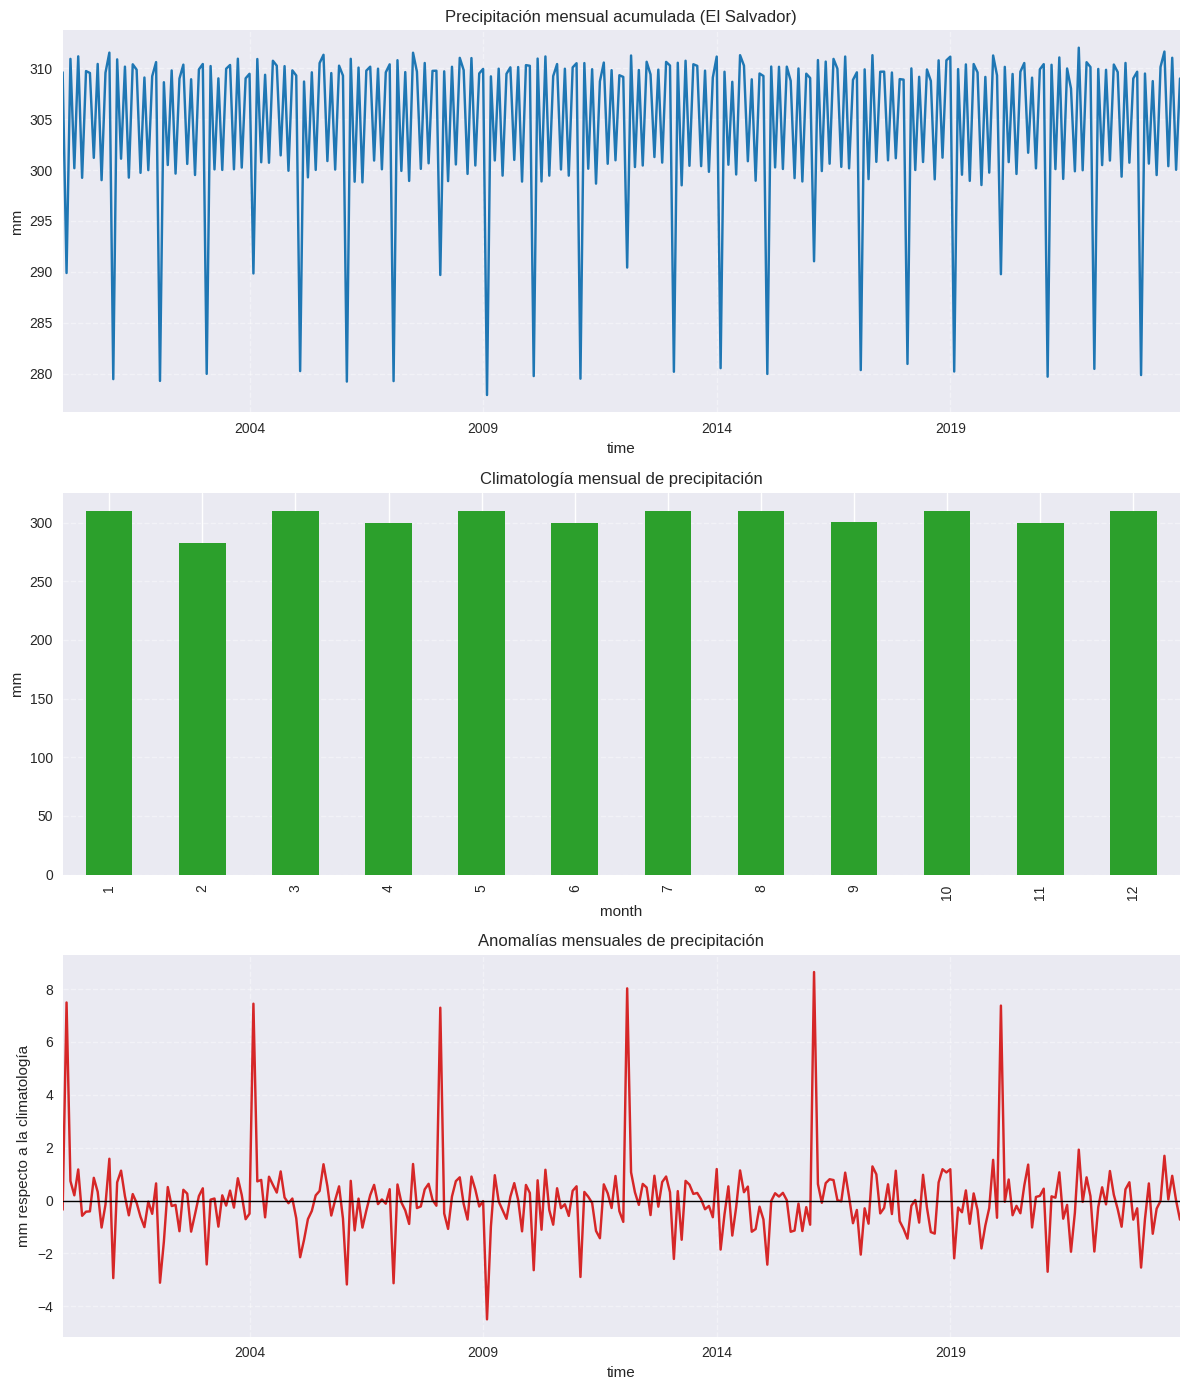

In [29]:
fig, ax = plt.subplots(3, 1, figsize=(12, 14), sharex=False)

precip_mensual_df.plot(ax=ax[0], color='tab:blue')
ax[0].set_title('Precipitación mensual acumulada (El Salvador)')
ax[0].set_ylabel('mm')
ax[0].grid(True, linestyle='--', alpha=0.4)

climatologia_df.plot(kind='bar', ax=ax[1], color='tab:green')
ax[1].set_title('Climatología mensual de precipitación')
ax[1].set_ylabel('mm')
ax[1].grid(True, axis='y', linestyle='--', alpha=0.4)

anomalias_df.plot(ax=ax[2], color='tab:red')
ax[2].axhline(0, color='black', linewidth=1)
ax[2].set_title('Anomalías mensuales de precipitación')
ax[2].set_ylabel('mm respecto a la climatología')
ax[2].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Observaciones preliminares

- Los máximos de precipitación se concentran típicamente en los meses de mayo a octubre, coherentes con la estación lluviosa centroamericana.
- Los mínimos se observan entre diciembre y marzo, reflejando la estación seca.
- Identifica años con anomalías positivas destacadas (p. ej., posibles eventos de tormentas tropicales) y negativos (sequías) comparando las barras de la climatología con la serie mensual.
- Se recomienda complementar este análisis con información agrícola local para interpretar impactos sobre cultivos clave.